In [1]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

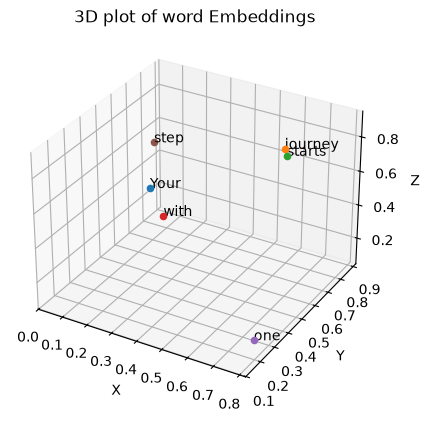

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

words = ['Your', 'journey', 'starts', 'with', 'one', 'step']

x_coords=inputs[:,0].numpy()
y_coords=inputs[:,1].numpy()
z_coords=inputs[:,2].numpy()

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')

for x, y,z, word in zip(x_coords,y_coords,z_coords,words):
    ax.scatter(x,y,z)
    ax.text(x,y,z,word,fontsize=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D plot of word Embeddings')
plt.show()

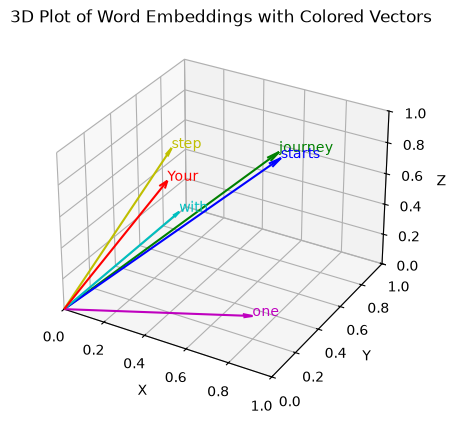

In [5]:
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()


In [6]:
query=inputs[1]
attn_scores_2=torch.empty(inputs.shape[0])
for i,x_i in enumerate(inputs):
    attn_scores_2[i]= torch.dot(x_i,query)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [9]:
attn_weights_2=attn_scores_2 /attn_scores_2.sum()

print("Attention weights:",attn_weight_2)
print("sum:",attn_weights_2.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
sum: tensor(1.0000)


In [10]:
def softmax_naive(x):
    return torch.exp(x)/torch.exp(x).sum(dim=0)

attn_weights_2_naive=softmax_naive(attn_scores_2)

print("Attention weights:",attn_weights_2_naive)
print("sum:",attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
sum: tensor(1.)


In [11]:
attn_weights_2=torch.softmax(attn_scores_2,dim=0)
print("Attention weights:",attn_weights_2)
print("sum:",attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
sum: tensor(1.)


In [13]:
query=inputs[1]
context_vec_2=torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 +=attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


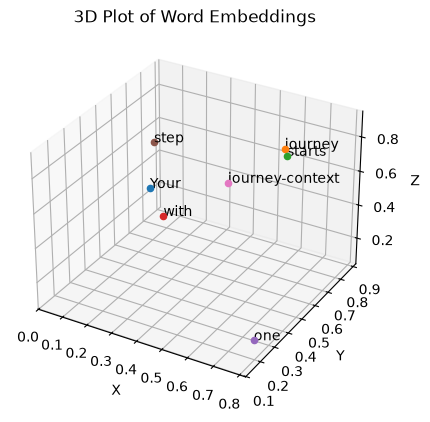

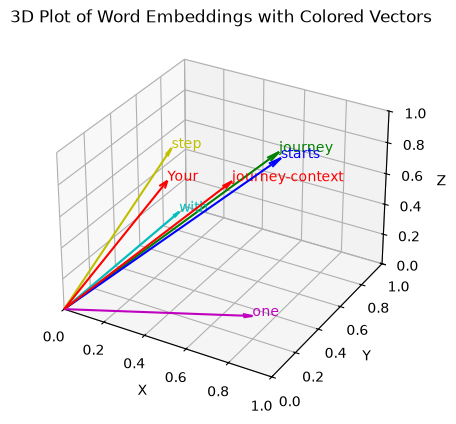

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55], # step     (x^6)
   [0.4419, 0.6515, 0.5683]]
)

# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

In [17]:

n=inputs.shape[0]
attn_scores=torch.empty(n,n)

for i ,x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i,j]=torch.dot(x_i,x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310, 0.7935],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865, 1.1849],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605, 1.1694],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565, 0.6626],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935, 0.5600],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450, 0.8559],
        [0.7935, 1.1849, 1.1694, 0.6626, 0.5600, 0.8559, 0.9427]])


In [18]:
attn_scores=inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310, 0.7935],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865, 1.1849],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605, 1.1694],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565, 0.6626],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935, 0.5600],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450, 0.8559],
        [0.7935, 1.1849, 1.1694, 0.6626, 0.5600, 0.8559, 0.9427]])


In [19]:
attn_weights=torch.softmax(attn_scores,dim=-1)
print(attn_weights)

tensor([[0.1792, 0.1713, 0.1692, 0.1061, 0.1042, 0.1240, 0.1459],
        [0.1180, 0.2026, 0.1986, 0.1056, 0.0921, 0.1346, 0.1486],
        [0.1184, 0.2017, 0.1981, 0.1058, 0.0943, 0.1332, 0.1485],
        [0.1223, 0.1768, 0.1744, 0.1246, 0.1077, 0.1467, 0.1476],
        [0.1305, 0.1675, 0.1689, 0.1169, 0.1607, 0.1108, 0.1446],
        [0.1180, 0.1861, 0.1813, 0.1211, 0.0842, 0.1615, 0.1478],
        [0.1277, 0.1889, 0.1860, 0.1121, 0.1011, 0.1359, 0.1483]])


In [20]:
row_2_sum=sum([0.1180, 0.2026, 0.1986, 0.1056, 0.0921, 0.1346, 0.1486])
print("Row 2 sum:",row_2_sum)
print("all row sums:",attn_weights.sum(dim=-1))

Row 2 sum: 1.0001
all row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [21]:
all_context_vecs=attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4420, 0.6016, 0.5774],
        [0.4419, 0.6515, 0.5683],
        [0.4429, 0.6499, 0.5673],
        [0.4321, 0.6330, 0.5536],
        [0.4635, 0.5997, 0.5326],
        [0.4213, 0.6505, 0.5651],
        [0.4397, 0.6372, 0.5635]])


In [22]:
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


In [23]:
x_2=inputs[1]
d_in=inputs.shape[1]
d_out=2

In [25]:
torch.manual_seed(123)
W_query=torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
W_key=torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
W_value=torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)

In [26]:
query_2=x_2 @ W_query
key_2=x_2 @ W_key
value_2=x_2 @ W_value
print(query_2)


tensor([0.4306, 1.4551])


In [29]:
keys=inputs @ W_key
values=inputs  @ W_value
print("keys.shape:",keys.shape)
print("values.shape:",values.shape)

keys.shape: torch.Size([7, 2])
values.shape: torch.Size([7, 2])


In [30]:
key_2=keys[1]
attn_score_22=query_2.dot(key_2)
print(attn_score_22)

tensor(1.8524)


In [32]:
attn_scores_2= query_2 @ keys.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440, 1.4775])


In [35]:
d_k=keys.shape[-1]
attn_weights_2=torch.softmax(attn_scores_2/d_k**0.5 ,dim=-1)
print(attn_weights_2)

tensor([0.1278, 0.1929, 0.1873, 0.1117, 0.0772, 0.1551, 0.1480])


In [36]:
context_vec_2=attn_weights_2 @ values
print(context_vec_2)

tensor([0.3062, 0.8207])


In [39]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self,d_in,d_out):
        super().__init__()
        self.W_query=nn.Parameter(torch.rand(d_in,d_out))
        self.W_key=nn.Parameter(torch.rand(d_in,d_out))
        self.W_value=nn.Parameter(torch.rand(d_in,d_out))

    def forward(self,x):
        keys=x@ self.W_key
        queries=x @ self.W_query
        values=x @ self.W_value
        
        attn_scores=queries @ keys.T
        attn_weights=torch.softmax(
            attn_scores / keys.shape[-1]**0.5 , dim=-1
        )
        context_vec=attn_weights @ values
        return context_vec

In [40]:
torch.manual_seed(123)
sa_v1=SelfAttention_v1(d_in,d_out)
print(sa_v1(inputs))

tensor([[0.3007, 0.8073],
        [0.3062, 0.8207],
        [0.3060, 0.8201],
        [0.2966, 0.7975],
        [0.2948, 0.7934],
        [0.3002, 0.8062],
        [0.3021, 0.8109]], grad_fn=<MmBackward0>)


In [41]:
class SelfAttention_v2(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec

In [42]:
torch.manual_seed(123)
sa_v2=SelfAttention_v2(d_in,d_out)
print(sa_v2(inputs))

tensor([[-0.5383, -0.1076],
        [-0.5371, -0.1100],
        [-0.5371, -0.1100],
        [-0.5348, -0.1097],
        [-0.5360, -0.1088],
        [-0.5350, -0.1101],
        [-0.5365, -0.1095]], grad_fn=<MmBackward0>)


In [43]:
queries =sa_v2.W_query(inputs)
keys=sa_v2.W_key(inputs)
attn_scores=queries @ keys.T
attn_weights= torch.softmax(attn_scores/ keys.shape[-1]**0.5,dim=1)
print(attn_weights)

tensor([[0.1469, 0.1508, 0.1507, 0.1331, 0.1392, 0.1351, 0.1441],
        [0.1400, 0.1497, 0.1494, 0.1380, 0.1374, 0.1414, 0.1441],
        [0.1401, 0.1497, 0.1494, 0.1379, 0.1374, 0.1413, 0.1441],
        [0.1402, 0.1459, 0.1458, 0.1415, 0.1398, 0.1434, 0.1435],
        [0.1428, 0.1475, 0.1474, 0.1385, 0.1398, 0.1404, 0.1437],
        [0.1391, 0.1464, 0.1461, 0.1417, 0.1391, 0.1440, 0.1435],
        [0.1412, 0.1486, 0.1484, 0.1383, 0.1385, 0.1410, 0.1439]],
       grad_fn=<SoftmaxBackward0>)


In [44]:
context_length=attn_scores.shape[0]
mask_simple=torch.tril(torch.ones(context_length,context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1.]])


In [45]:
masked_simple=attn_weights*mask_simple
print(masked_simple)

tensor([[0.1469, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1400, 0.1497, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1401, 0.1497, 0.1494, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1402, 0.1459, 0.1458, 0.1415, 0.0000, 0.0000, 0.0000],
        [0.1428, 0.1475, 0.1474, 0.1385, 0.1398, 0.0000, 0.0000],
        [0.1391, 0.1464, 0.1461, 0.1417, 0.1391, 0.1440, 0.0000],
        [0.1412, 0.1486, 0.1484, 0.1383, 0.1385, 0.1410, 0.1439]],
       grad_fn=<MulBackward0>)


In [46]:
row_sums=masked_simple.sum(dim=1,keepdim=True)
masked_simple_norm=masked_simple /row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4833, 0.5167, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3190, 0.3408, 0.3402, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2445, 0.2545, 0.2542, 0.2468, 0.0000, 0.0000, 0.0000],
        [0.1994, 0.2060, 0.2058, 0.1935, 0.1953, 0.0000, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682, 0.0000],
        [0.1412, 0.1486, 0.1484, 0.1383, 0.1385, 0.1410, 0.1439]],
       grad_fn=<DivBackward0>)


In [48]:
mask=torch.triu(torch.ones(context_length,context_length),diagonal=1)
masked=attn_scores.masked_fill(mask.bool(),-torch.inf)
print(masked)

tensor([[0.3111,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.1655, 0.2602,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.1667, 0.2602, 0.2577,   -inf,   -inf,   -inf,   -inf],
        [0.0510, 0.1080, 0.1064, 0.0643,   -inf,   -inf,   -inf],
        [0.1415, 0.1875, 0.1863, 0.0987, 0.1121,   -inf,   -inf],
        [0.0476, 0.1192, 0.1171, 0.0731, 0.0477, 0.0966,   -inf],
        [0.1505, 0.2233, 0.2213, 0.1220, 0.1235, 0.1493, 0.1777]],
       grad_fn=<MaskedFillBackward0>)


In [49]:
attn_weights=torch.softmax(masked/keys.shape[-1]**0.5,dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4833, 0.5167, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3190, 0.3408, 0.3402, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2445, 0.2545, 0.2542, 0.2468, 0.0000, 0.0000, 0.0000],
        [0.1994, 0.2060, 0.2058, 0.1935, 0.1953, 0.0000, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682, 0.0000],
        [0.1412, 0.1486, 0.1484, 0.1383, 0.1385, 0.1410, 0.1439]],
       grad_fn=<SoftmaxBackward0>)


In [55]:
torch.manual_seed(123)
dropout=torch.nn.Dropout(0.5)
ex=torch.ones(6,6)
print(dropout(ex))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [56]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6380, 0.6816, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.5085, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4120, 0.0000, 0.3869, 0.3906, 0.0000, 0.0000],
        [0.0000, 0.3418, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.2968, 0.0000, 0.2770, 0.2821, 0.0000]],
       grad_fn=<MulBackward0>)


In [57]:
batch=torch.stack((inputs,inputs),dim=0)
print(batch.shape)

torch.Size([2, 7, 3])


In [60]:
class CasualAttention(nn.Module):

    def __init__(self,d_in,d_out,context_length,dropout,qkv_bias=False):
        super().__init__()
        self.d_out=d_out
        self.W_query=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_key=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_value=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.dropout=nn.Dropout(dropout)
        self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))
    
    def forward(self,x):
        b,num_tokens,d_in=x.shape
        keys=self.W_key(x)
        queries=self.W_query(x)
        values=self.W_value(x)

        attn_scores=queries @ keys.transpose(1,2)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens,:num_tokens],-torch.inf
        )
        attn_weights=torch.softmax(
            attn_scores /keys.shape[-1]**0.5,dim=-1
        )
        attn_weights=self.dropout(attn_weights)
        context_vec=attn_weights @ values
        return context_vec

In [61]:
torch.manual_seed(123)
context_length=batch.shape[1]
ca=CasualAttention(d_in,d_out,context_length,0.1)
context_vecs=ca(batch)
print("context_vecs.shape:",context_vecs.shape)

context_vecs.shape: torch.Size([2, 7, 2])


In [62]:
print(context_vecs)

tensor([[[-0.5021,  0.2462],
         [-0.6527,  0.0064],
         [-0.7000, -0.0702],
         [-0.6305, -0.0936],
         [-0.6140, -0.1090],
         [-0.3654, -0.0540],
         [-0.5376, -0.0978]],

        [[ 0.0000,  0.0000],
         [-0.6527,  0.0064],
         [-0.7000, -0.0702],
         [-0.6305, -0.0936],
         [-0.5138, -0.1581],
         [-0.5888, -0.1201],
         [-0.4786, -0.0892]]], grad_fn=<UnsafeViewBackward0>)


In [63]:
class MultiHeadAttentionWrapper(nn.Module):
    
    def __init__(self,d_in,d_out,context ,dropout,num_heads,qkv_bias=False):
        super().__init__()
        self.heads=nn.ModuleList(
            [CasualAttention(d_in,d_out,context_length,dropout,qkv_bias)
            for _ in range(num_heads)]
        )
    
    def forward(self,x):
        return torch.cat([head(x) for head in self.heads],dim=-1)

In [64]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)
batch=torch.stack((inputs,inputs),dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [67]:
torch.manual_seed(123)
context_length=batch.shape[1]
d_in, d_out=3,2
mha=MultiHeadAttentionWrapper(d_in,d_out,context_length,0.0,num_heads=5)
context_vecs=mha(batch)
print(context_vecs)
print("context_vecs",context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063,  0.4566,  0.2729, -0.5684,
           0.5063, -0.4821,  0.4336],
         [-0.5874,  0.0058,  0.5891,  0.3257,  0.5792,  0.3011, -0.5388,
           0.6447, -0.5368,  0.5483],
         [-0.6300, -0.0632,  0.6202,  0.3860,  0.6249,  0.3102, -0.5242,
           0.6954, -0.5545,  0.5886],
         [-0.5675, -0.0843,  0.5478,  0.3589,  0.5691,  0.2785, -0.4578,
           0.6471, -0.4937,  0.5311],
         [-0.5526, -0.0981,  0.5321,  0.3428,  0.5543,  0.2520, -0.4006,
           0.5921, -0.4589,  0.5169],
         [-0.5299, -0.1081,  0.5077,  0.3493,  0.5337,  0.2499, -0.3997,
           0.5971, -0.4479,  0.4971]],

        [[-0.4519,  0.2216,  0.4772,  0.1063,  0.4566,  0.2729, -0.5684,
           0.5063, -0.4821,  0.4336],
         [-0.5874,  0.0058,  0.5891,  0.3257,  0.5792,  0.3011, -0.5388,
           0.6447, -0.5368,  0.5483],
         [-0.6300, -0.0632,  0.6202,  0.3860,  0.6249,  0.3102, -0.5242,
           0.6954, -0.5545,  0.5886],